---

# Итоговый отчёт: обучение LLM-агента в среде Target24 с помощью GRPO и curriculum learning

---

## 1. Цель работы

Цель — реализовать среду для RL-обучения LLM-агента, где:

* ответ **верифицируем**;
* сложность **регулируется**;
* задача решается **за один шаг** (один запрос к LLM);
* затем обучить LLM-агента алгоритмом Reinforcement Learning (GRPO) и сравнить качество до/после обучения на тестовых наборах разных сложностей. 

---

## 2. Постановка задачи (среда Target24)

### 2.1. Описание задачи

Агенту выдаётся набор чисел и целевое значение `Target`. Нужно построить **арифметическое выражение**, используя **каждое число ровно один раз**, чтобы результат выражения был равен `Target`.

### 2.2. Правила (как в промпте среды)

В среде задаются правила:

* использовать каждое число **ровно один раз**;
* разрешённые операции: `+ - * /`;
* **запрещено** вводить новые числовые литералы;
* деление на ноль запрещено;
* деление разрешено **только если результат целый** (exact division);
* скобки могут быть разрешены или запрещены (зависит от уровня сложности);
* ответ требуется в формате:

  ```text
  <answer>
  YOUR_EXPRESSION_HERE
  </answer>
  ```

Эти правила формируются в `build_prompt(...)`. 

---

## 3. Регулировка сложности: curriculum уровни 1–5

Сложность задаётся параметром `difficulty` (в данной реализации это 1–5) и переводится в конфигурацию количества чисел и разрешения скобок:

* **Level 1:** 2 числа, 1 оператор, **без скобок**
* **Level 2:** 3 числа, 2 оператора, **без скобок**
* **Level 3:** 3 числа, 2 оператора, **скобки разрешены** (gold может использовать скобки)
* **Level 4:** 4 числа, 3 оператора, **без скобок**
* **Level 5:** 4 числа, 3 оператора, **скобки разрешены** (gold может использовать скобки)

Конфигурация уровней задаётся в методе `_level_cfg` среды. 

---

## 4. Верификация решения (Verifier)

### 4.1. Извлечение ответа

Из генерации LLM извлекается содержимое тега `<answer> ... </answer>` регулярным выражением. 

### 4.2. Проверка корректности

Проверка устроена строго:

* выражение парсится в AST;
* разрешены только бинарные операции из допустимого набора;
* запрещены унарные операции (например, `-3`);
* все “листья” AST должны быть **целыми числами**;
* мультимножество использованных чисел должно **совпасть** с выданными числами;
* количество бинарных операций должно быть ровно `N-1` (чтобы не было скрытых констант/трюков);
* деление допускается только при `a % b == 0` (точное целочисленное). 

Итог: `verify(...)` возвращает `True` только если выражение валидно и вычисленное значение равно `Target`.

---

## 5. Данные

### 5.1. Генерация обучающего набора

Генерация в среде сделана “обратным способом”: сначала случайно строится корректное выражение под ограничения уровня, затем оно вычисляется (по правилам integer-арифметики), и полученное значение становится `Target`. Это гарантирует **разрешимость** задач при генерации. 

Параметры генерации по умолчанию (если не переопределять):

* числа: от 1 до 9;
* допустимые операции: `+ - * /`;
* target: от 0 до 1000;
* на уровнях 3 и 5 может требоваться использование скобок (через `require_parentheses_on_levels_3_5`). 

### 5.2. Размеры датасетов

Использованы:

* **train:** суммарно **62 000** задач, распределение по уровням:
  L1: 2 000, L2: 4 000, L3: 8 000, L4: 16 000, L5: 32 000.
* **test:** по **500** задач на каждый уровень (фиксированные, не пересэмпливаются).

**Таблица 1. Размеры датасетов**

| Уровень   |      Train |      Test |
| --------- | ---------: | --------: |
| L1        |      2 000 |       500 |
| L2        |      4 000 |       500 |
| L3        |      8 000 |       500 |
| L4        |     16 000 |       500 |
| L5        |     32 000 |       500 |
| **Итого** | **62 000** | **2 500** |

---

## 6. Обучение: GRPO + curriculum learning

### 6.1. Базовая модель и адаптация

* Базовая модель: `unsloth/Qwen2.5-1.5B-Instruct`
* Контекст: `MAX_SEQ_LENGTH = 512`
* Обучение через LoRA:

  * `r = 16`
  * target modules: `q_proj, k_proj, v_proj, o_proj, gate_proj, up_proj, down_proj`
  * `lora_alpha = 16`, `lora_dropout = 0.0`
  * 4-bit загрузка (экономия памяти)

(см. `GRPO_curriculum.ipynb`, блок “Load model + LoRA”.)

### 6.2. System prompt и формат ответа

Используется system prompt, требующий структуру:

```text
<think>...</think>
<answer>...</answer>
```

и правила внутри `<answer>` (одно выражение, без новых чисел, точное деление, учёт скобок). Это снижает “шум” и упрощает верификацию.

### 6.3. Параметры GRPO

Основные параметры (как в конфиге обучения):

**Таблица 2. Гиперпараметры GRPO**

| Параметр                    | Значение   |
| --------------------------- | ---------- |
| learning_rate               | 5e-6       |
| optim                       | adamw_8bit |
| lr_scheduler_type           | cosine     |
| warmup_ratio                | 0.05       |
| per_device_train_batch_size | 1          |
| gradient_accumulation_steps | 1          |
| num_generations             | 2          |
| max_prompt_length           | 256        |
| max_completion_length       | 96         |
| use_vllm                    | False      |
| seed                        | 42         |

### 6.4. Curriculum schedule

Обучение идёт по уровням 1 → 5, фиксированное число GRPO-шагов на уровень:

**Таблица 3. Расписание curriculum**

| Уровень | GRPO steps |
| ------- | ---------: |
| L1      |        200 |
| L2      |        300 |
| L3      |        400 |
| L4      |        600 |
| L5      |        800 |

Опционально в коде предусмотрен режим смешивания прошлых уровней (`MIX_PREVIOUS_LEVELS`), но в текущем запуске использован строгий curriculum (по одному уровню за раз).

---

## 7. Reward shaping (награды)

Чтобы сигнал обучения был не только “0/1 за правильность”, использованы компоненты награды:

1. **Format reward**: за наличие `<think>` и `<answer>`, и за “почти строгий” формат начала/конца.
2. **Validity reward**: если выражение синтаксически корректно и валидно по правилам среды (числа использованы правильно, деление точное, скобки по правилам).
3. **Distance reward**: если выражение валидно, то награда тем выше, чем ближе значение к target:
   [
   r = \frac{0.30}{1 + |val - target|}
   ]
4. **Correctness reward** (главная): 1.0, если `env.verify(...) == True`, иначе 0.0.

Итоговая награда — сумма компонент (в GRPO используется список reward-функций). Логика компонент реализована в ноутбуке обучения.

---

## 8. Метрики и методика оценки

### 8.1. Метрика качества

Основная метрика: **accuracy** = доля задач, где `verify=True` на фиксированном тестовом наборе соответствующего уровня.

Дополнительно логируется:

* `bad_format`: сколько ответов не соответствует ожидаемому формату (или не содержит `<answer>`).

### 8.2. Сравнение с baseline

Baseline — та же модель, но **без подключенного LoRA-адаптера** (“adapter OFF”), оценивается на текущем уровне.

---

## 9. Результаты

### 9.1. Итоговая точность по уровням (baseline vs GRPO)

Парные бары accuracy по уровням (baseline vs GRPO).
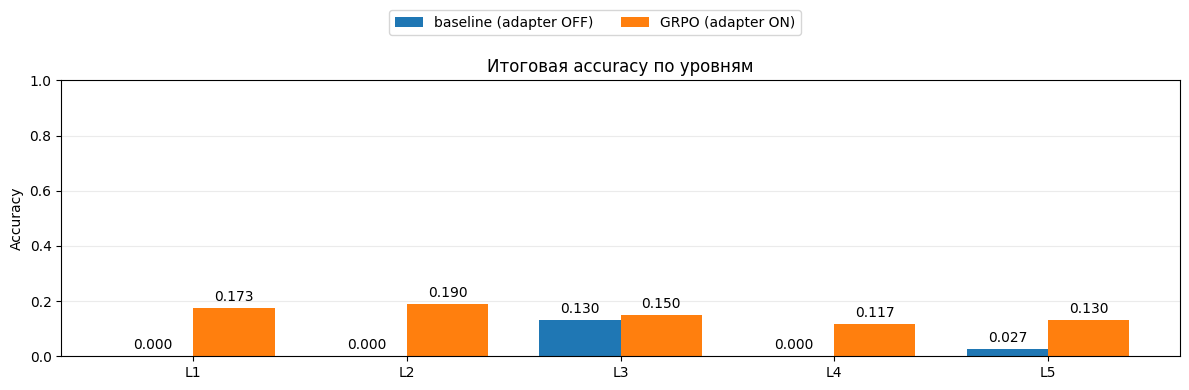

По этому графику наблюдаются следующие значения accuracy:

**Accuracy baseline vs GRPO (по уровням)**

| Уровень | Baseline acc | GRPO acc |
| ------- | -----------: | -------: |
| L1      |        0.000 |    0.173 |
| L2      |        0.000 |    0.190 |
| L3      |        0.130 |    0.150 |
| L4      |        0.000 |    0.117 |
| L5      |        0.027 |    0.130 |


**Вывод:** GRPO даёт устойчивый прирост на всех уровнях. При этом абсолютные значения на старших уровнях остаются ограниченными — задача со скобками/4 числами заметно сложнее для короткого обучения.

---

### 9.2. Forgetting / перенос между уровнями

Линии accuracy по тестам L1..L5 после каждого этапа curriculum.
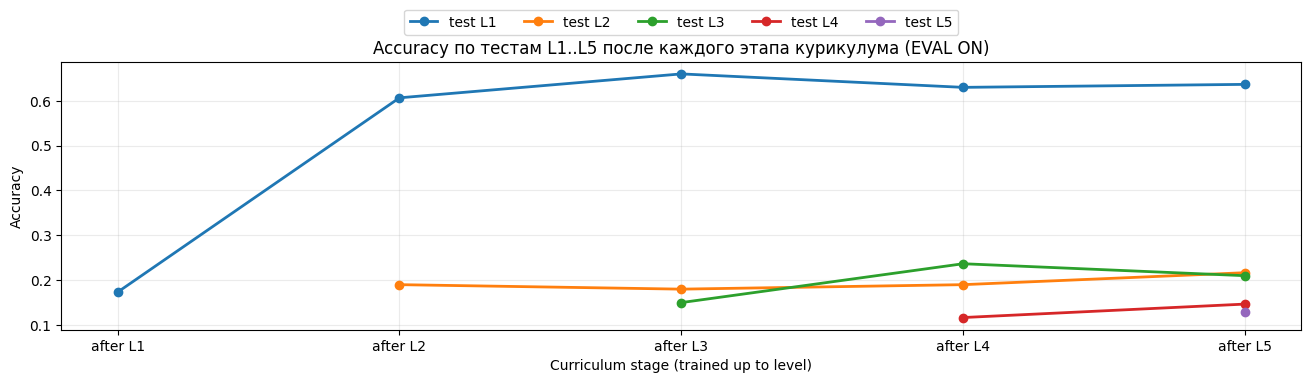

Тепловая карта accuracy (stage × test-level).
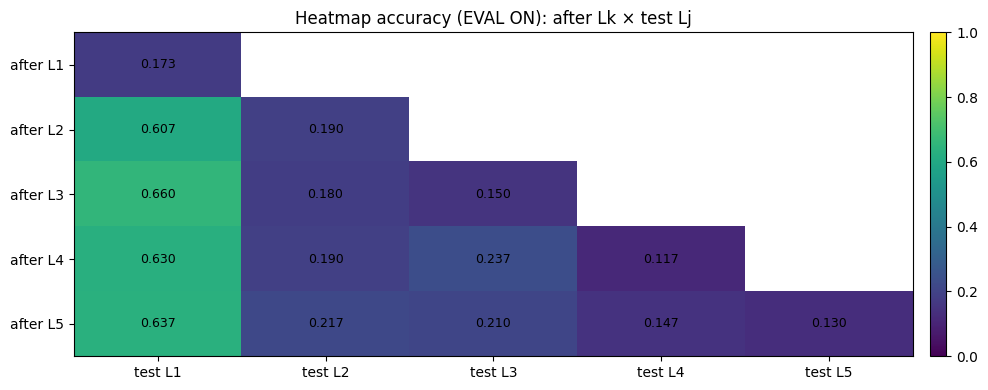

Ключевое наблюдение: после обучения на более сложных уровнях качество на самом простом уровне **в целом сохраняется**, но на сложных уровнях accuracy растёт медленнее, вероятно из-за:

* более длинного пространства выражений (особенно со скобками),
* ограниченного числа шагов обучения, количества генераций и маленького batch.

---

### 9.3. Динамика обучения: reward и KL
Reward по шагам обучения (по уровням).
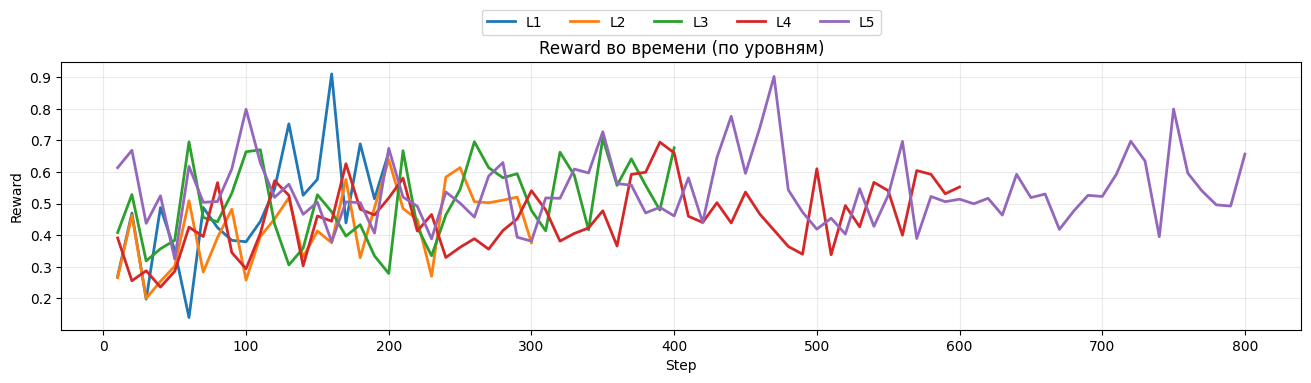

KL-дивергенция по шагам обучения (по уровням).
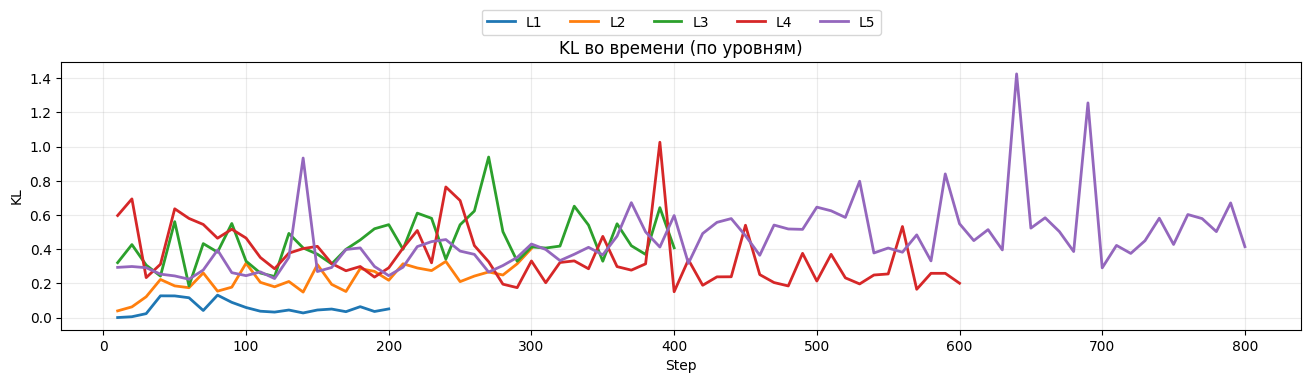

Типичное поведение:

* reward постепенно растёт (агент чаще генерирует валидные/близкие/правильные выражения),
* KL контролируемая (модель не “разваливается” в режим случайных ответов).

---

### 9.4. Компоненты награды

Компоненты reward (format/validity/distance/correctness/total) отдельно для L1..L5.
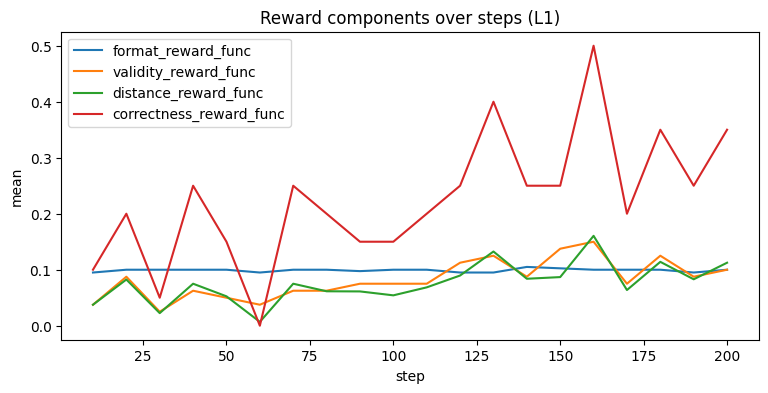

Интерпретация:

* format-часть быстро “включается” (модель учится ставить теги),
* validity и distance помогают получить плотный сигнал даже до появления большого числа полностью правильных решений,
* correctness остаётся разреженным и растёт медленнее, особенно на L5.

---

### 9.5. Анализ типов ошибок

Мы классифицируем неверные ответы по причинам, близким к логике валидатора:

1) **bad_format** — нет блока `<answer>...</answer>` или он пустой.  
2) **forbidden_parentheses** — на уровне, где скобки запрещены, в выражении есть `(` или `)`.  
3) **syntax_error** — выражение не парсится в AST (ошибка синтаксиса).  
4) **invalid_tokens_or_ops** — встречаются запрещённые операции/токены, нецелые числа, унарные операции и т.д.  
5) **wrong_op_count** — число бинарных операций не равно `len(numbers)-1`.  
6) **numbers_mismatch** — использованы не все числа, есть лишние или не те числа.  
7) **division_by_zero** — деление на ноль.  
8) **non_exact_division** — деление даёт нецелый результат (по правилам запрещено).  
9) **wrong_value** — выражение валидно и использует все числа, но значение ≠ target.  
10) **correct** — проходит `env.verify`.

Важно: “перестановка чисел” **не считается ошибкой**, если валидатор сравнивает числа как мультимножество (текущая версия именно такая).

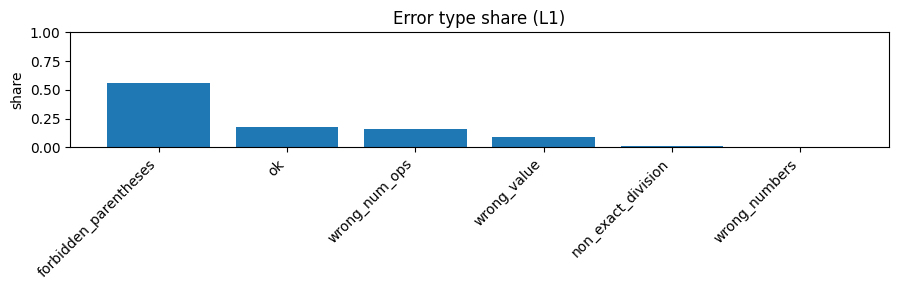
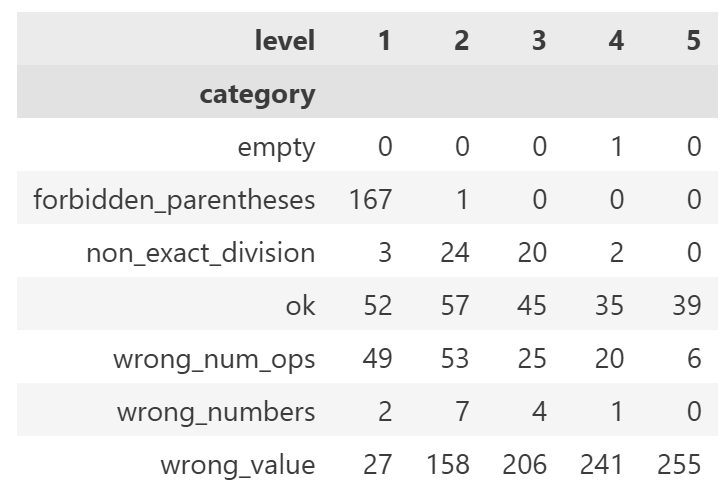
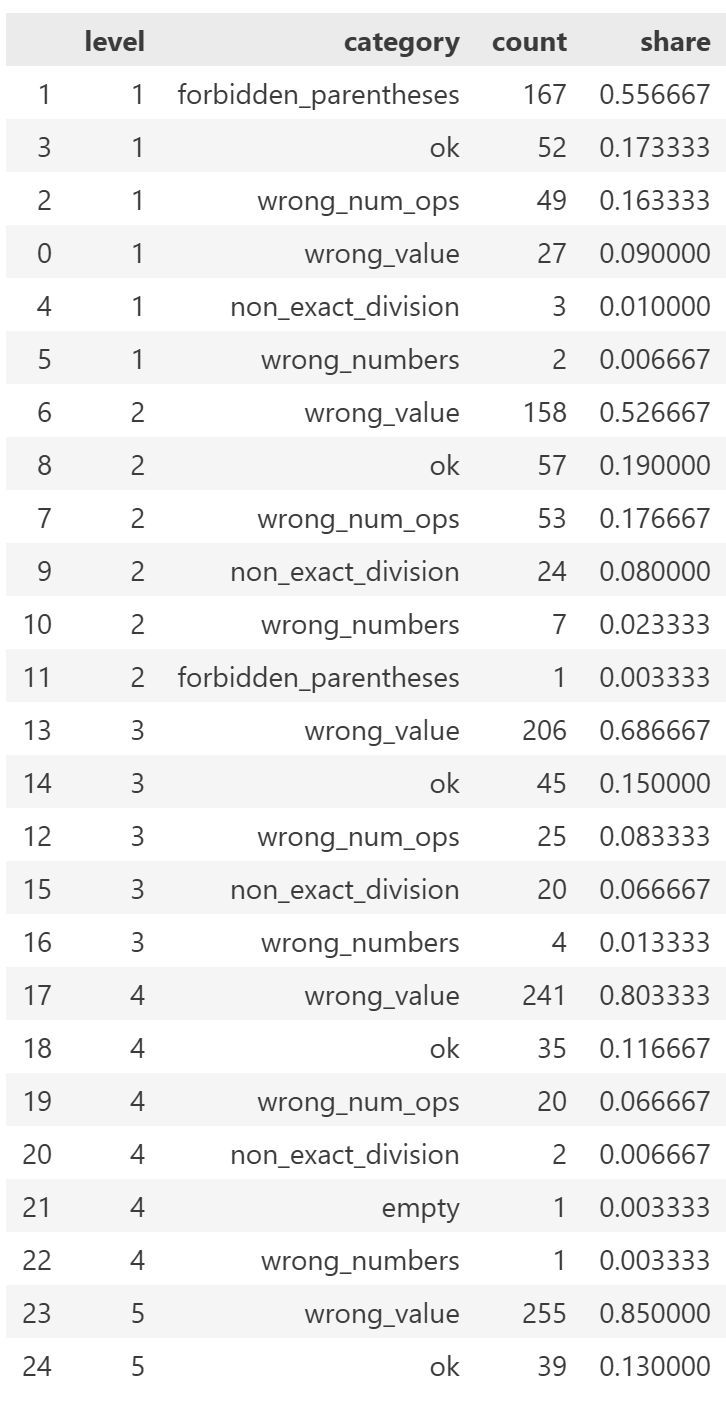

Качественно доминируют три класса проблем:

1. **Неверный таргет при формально валидном выражении** (самая частая причина на сложных уровнях).
2. **Невалидное выражение** (не те числа, лишние/пропущенные числа, запрещённое деление).
3. **Ошибки формата** (реже, благодаря format reward).


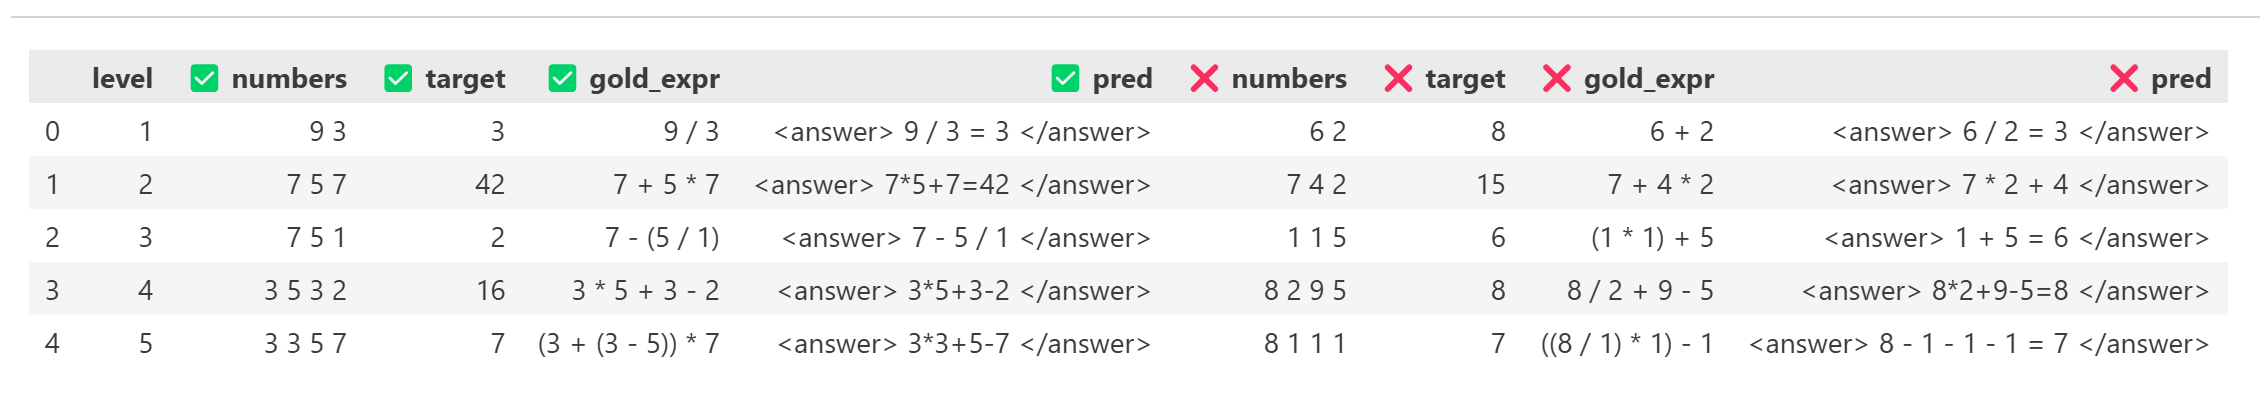

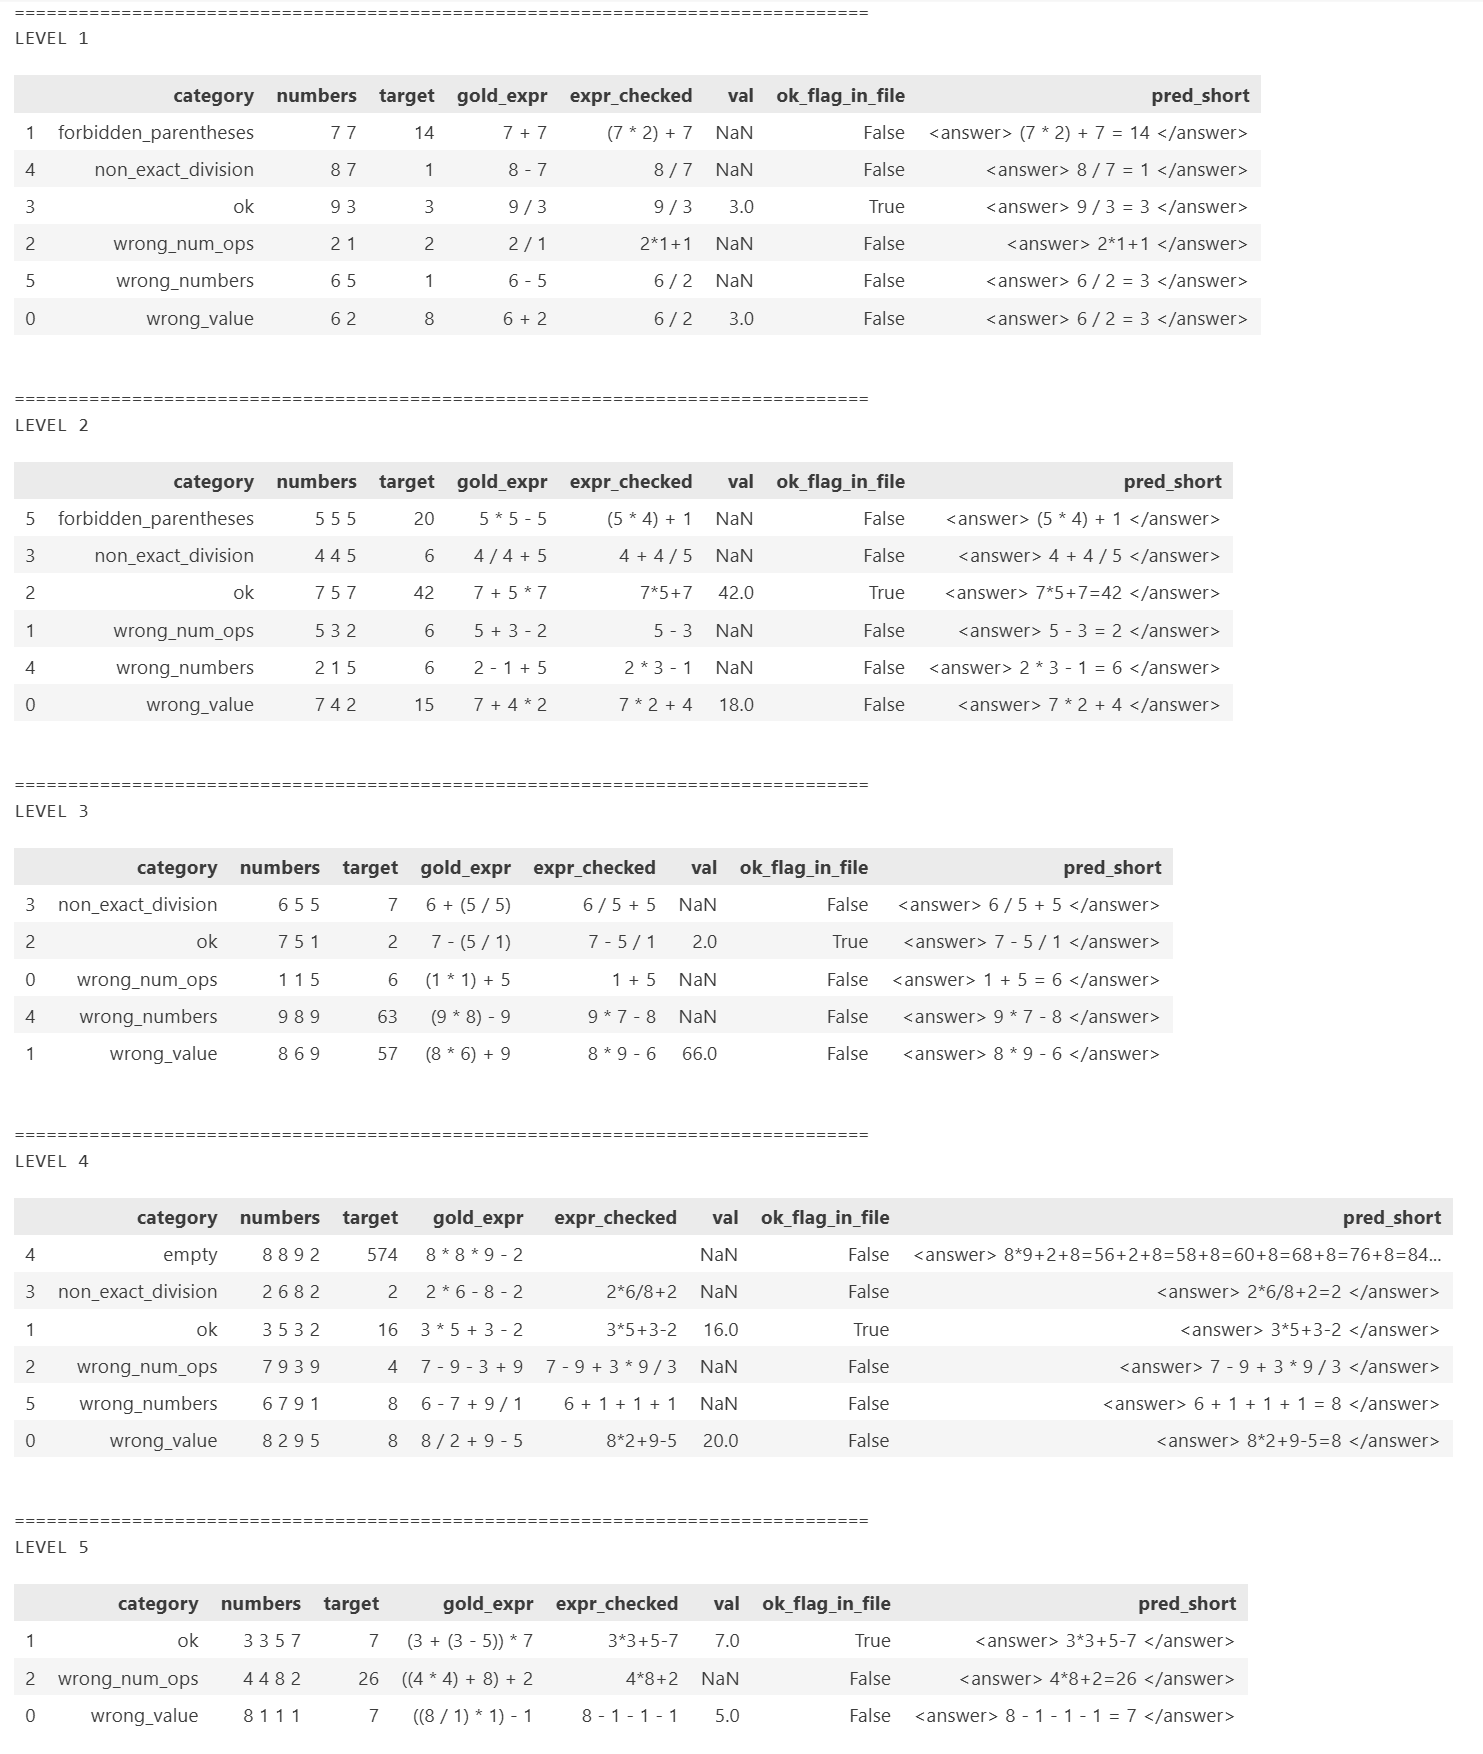
---

## 10. Выводы

1. Среда Target24 удовлетворяет требованиям задания: ответ верифицируем, сложность регулируется, решение в один шаг. 
2. Реализован строгий verifier на AST, исключающий “читинг” (новые числа, неправильное количество операций, неточное деление). 
3. GRPO с curriculum learning улучшает accuracy относительно baseline на каждом уровне.
4. Наиболее сложный уровень (4 числа + скобки) остаётся проблемным: нужен либо больший бюджет шагов, либо улучшения reward/данных.

---

## 11. Идеи улучшений (что бы я сделала дальше)

### 11.1. Улучшения обучения

* Увеличить `STEPS_PER_LEVEL` (особенно для L4–L5).
* Включить `MIX_PREVIOUS_LEVELS=True` после L3, чтобы стабилизировать перенос и снизить риск забывания.
* Увеличить `num_generations` (больше семплов → лучше оценка reward, но дороже).
* Попробовать `use_vllm=True` на инференсе/оценке для ускорения (если инфраструктура позволяет).

### 11.2. Улучшения reward shaping

* Штраф за “почти валидно”: например, если выражение валидно, но использует неверный набор чисел (сейчас это просто 0 по validity).
* Добавить небольшой штраф за слишком длинные/сложные выражения (чтобы не было мусорных скобок).
* Нормировать веса компонент, чтобы correctness не “тонул” на поздних уровнях.

### 11.3. Улучшения данных

* Добавить больше примеров, где обязательно нужны скобки (особенно для L5), чтобы модель училась структурам.
* Балансировать генерацию по типам выражений (линейные vs разветвлённые со скобками), чтобы не было перекоса.

### 11.4. Улучшения формата ответа

* Сделать более жёсткий парсинг и explicit-penalty за любой текст внутри `<answer>`, кроме выражения (сейчас модель может иногда “болтать”).

---